In [1]:
from object_detection.utils import label_map_util
from object_detection.utils import visualization_utils as viz_utils
from object_detection.utils import ops as utils_ops
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_hub as hub
%matplotlib inline


c:\Users\KDS23\Documents\17-image\.venv\lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [2]:
PATH_TO_LABELS = './models/research/object_detection/data/mscoco_label_map.pbtxt'
category_index = label_map_util.create_category_index_from_labelmap(PATH_TO_LABELS, use_display_name=True)
hub_model = hub.load('https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_640x640/1')

In [3]:
# !wget https://raw.githubusercontent.com/Lilcob/test_colab/main/three%20young%20man.jpg
image_path = './three_young_man.jpg'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_np = np.array([image])

In [4]:
results = hub_model(image_np)
result = {key: value.numpy() for key, value in results.items()}
print(result.keys())

label_id_offset = 0
image_np_with_detections = image_np.copy()


dict_keys(['raw_detection_boxes', 'detection_multiclass_scores', 'detection_classes', 'detection_boxes', 'raw_detection_scores', 'num_detections', 'detection_anchor_indices', 'detection_scores'])


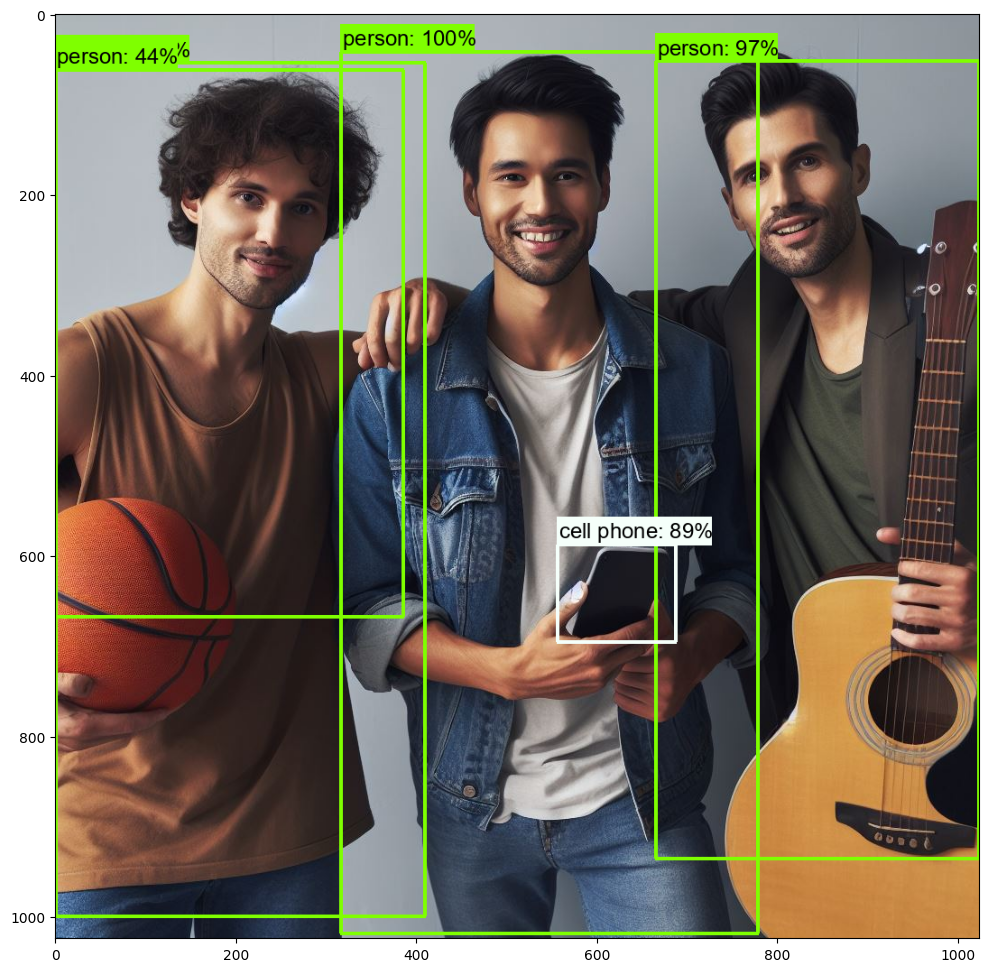

In [5]:
viz_utils.visualize_boxes_and_labels_on_image_array(
    image_np_with_detections[0],result['detection_boxes'][0],
(result['detection_classes'][0] + label_id_offset).astype(int),
 result['detection_scores'][0],category_index,use_normalized_coordinates=True, max_boxes_to_draw=200,min_score_thresh=.30,
agnostic_mode=False)
plt.figure(figsize=(12, 12))
plt.imshow(image_np_with_detections[0])
plt.show()